# 07  What the model actually uses

RQ 2.1.4: *which transactional features contribute most to performance?*

Three views, because each answers a different question and they disagree in informative ways:

| method | question it answers |
|---|---|
| **XGBoost gain** | which features did the trees split on, and how profitably? |
| **Permutation importance** | how much does test performance drop if a feature is scrambled? |
| **SHAP** | for each individual transaction, what pushed its score up or down? |

Gain is cheap but biased toward high-cardinality features. Permutation measures what the *model as deployed* depends on, and is the honest answer for "can we drop this feature?". SHAP is the only one that explains a single decision  which is what the prototype needs when an analyst asks *why was this flagged?*

**This runs at the experimental rung, not the full feature set.** On the full set the answer is trivially "the balance-error feature", which tells us about PaySim's simulator rather than about fraud. Here the origin-balance block is gone, so what remains is the signal that survives the artifact.

Lokanan (2023) Fig 5 reports his top five as **amount, type_TRANSFER, newbalanceDest, oldbalanceDest, type_CASH_OUT**  all of which exist at this rung, so the comparison is direct.

In [1]:
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import constants as C
from momo_fraud import data as D
from momo_fraud import evaluate as E
from momo_fraud import models as M
from momo_fraud import splits as S
from momo_fraud import viz
from momo_fraud.features import FeatureBuilder, columns_for

viz.apply_house_style()

decision = json.loads((PROJECT_ROOT / "results" / "03_experimental_rung.json").read_text())
RUNG = decision["experimental_rung"]
SEED = C.RANDOM_SEED
LEARNER = "xgboost"          # lowest NER in notebook 04
SHAP_SAMPLE = 60_000
PERM_SAMPLE = 200_000

df = D.load()
y = df[C.TARGET].to_numpy()
split = S.stratified_split(y)

builder = FeatureBuilder().fit(df.iloc[split.train])
X_all = builder.transform(df)
cols = columns_for(RUNG, list(X_all.columns))

X_train, y_train = X_all.iloc[split.train][cols], y[split.train]
X_test, y_test = X_all.iloc[split.test][cols], y[split.test]
print(f"rung {RUNG} | {len(cols)} features | learner {LEARNER}")

rung no_origin_balance | 14 features | learner xgboost


In [2]:
# Refit rather than reuse a cached score vector: SHAP and permutation both
# need the estimator itself, not its predictions.
start = time.perf_counter()
model = M.make_learner(LEARNER, seed=SEED)
model.fit(X_train, y_train)
print(f"refit in {time.perf_counter() - start:.0f}s")

refit in 205s


## Gain importance

How much each feature improved the loss across every split it was used in. Fast, but it rewards features with many possible split points, so it should not be read alone.

In [3]:
booster = model.get_booster()
gain_raw = booster.get_score(importance_type="gain")

gain = (pd.Series({c: gain_raw.get(c, 0.0) for c in cols}, name="gain")
        .sort_values(ascending=False))
gain_norm = (gain / gain.sum()).rename("gain_share")
E.save_results(gain_norm.reset_index().rename(columns={"index": "feature"})
               .to_dict("records"), "07_gain_importance")
gain_norm.round(4)

destZeroBefore    0.6029
type_TRANSFER     0.1582
destZeroAfter     0.0791
type_CASH_OUT     0.0409
hour              0.0378
amount            0.0314
type_CASH_IN      0.0131
newbalanceDest    0.0121
day               0.0097
type_PAYMENT      0.0059
highRiskFlag      0.0045
oldbalanceDest    0.0028
log_amount        0.0016
type_DEBIT        0.0000
Name: gain_share, dtype: float64

## Permutation importance

Scramble one feature and measure how far PR-AUC falls. This is the operationally meaningful measure  it answers *"what breaks if this signal becomes unavailable?"*, which is the real question when a feature depends on a system that might go down.

Scored on a stratified subsample: permutation needs `n_features × n_repeats` full scoring passes, and every fraud case is kept so the metric stays stable at 0.129% prevalence.

In [4]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

idx, _ = train_test_split(np.arange(len(y_test)), train_size=PERM_SAMPLE,
                          stratify=y_test, random_state=SEED)
X_perm, y_perm = X_test.iloc[idx], y_test[idx]
print(f"permutation sample: {len(y_perm):,} rows, {int(y_perm.sum()):,} fraud")

start = time.perf_counter()
perm = permutation_importance(model, X_perm, y_perm, scoring="average_precision",
                              n_repeats=5, random_state=SEED, n_jobs=1)
print(f"permutation importance in {time.perf_counter() - start:.0f}s")

perm_df = (pd.DataFrame({"feature": cols,
                         "drop": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("drop", ascending=False))
E.save_results(perm_df.to_dict("records"), "07_permutation_importance")
perm_df.round(4)

permutation sample: 200,000 rows, 258 fraud


permutation importance in 107s


,feature,drop,std
13,type_TRANSFER,0.7007,0.0089
3,newbalanceDest,0.5281,0.0094
0,amount,0.4471,0.0222
7,destZeroAfter,0.2924,0.0099
10,type_CASH_OUT,0.2676,0.0135
4,hour,0.2311,0.0134
5,day,0.2068,0.0078
2,oldbalanceDest,0.1541,0.0082
6,destZeroBefore,0.1398,0.0058
1,log_amount,0.0099,0.0040


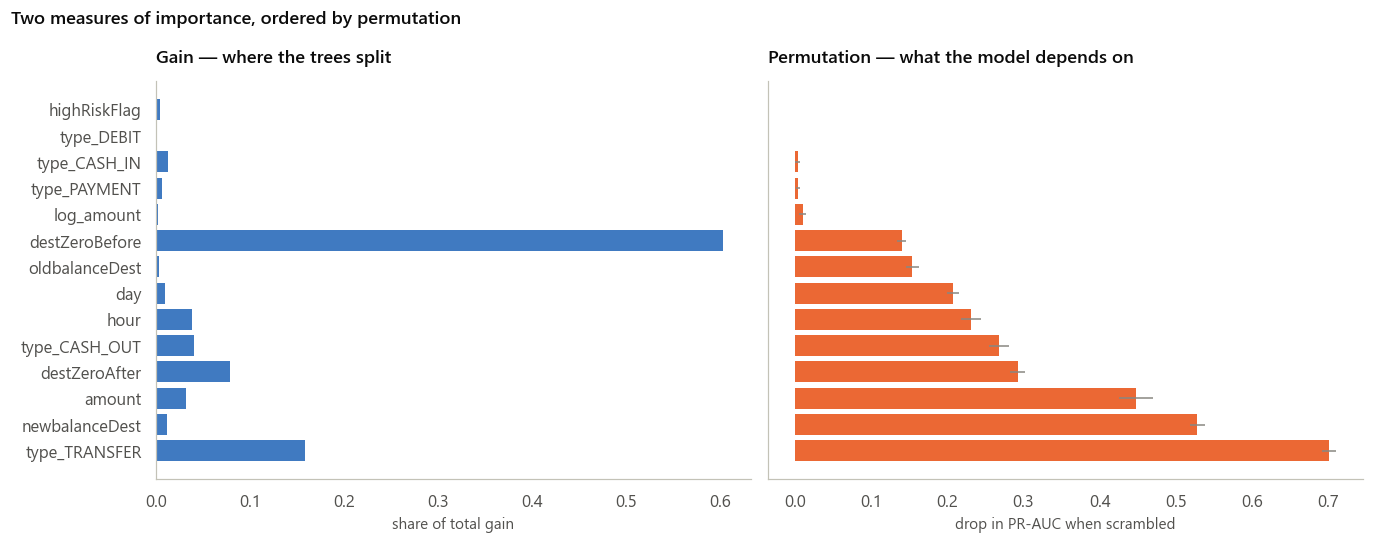

In [5]:
fig, (ax_gain, ax_perm) = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
order = perm_df["feature"].tolist()

sns.barplot(x=gain_norm.reindex(order).values, y=order,
            color=viz.CATEGORICAL[0], ax=ax_gain)
ax_gain.set(title="Gain  where the trees split", xlabel="share of total gain", ylabel="")

ax_perm.barh(range(len(order)), perm_df["drop"], xerr=perm_df["std"],
             color=viz.CATEGORICAL[1], error_kw={"linewidth": 1, "ecolor": viz.INK["muted"]})
ax_perm.set_yticks(range(len(order)))
ax_perm.set_yticklabels(order)
ax_perm.invert_yaxis()
ax_perm.set(title="Permutation  what the model depends on",
            xlabel="drop in PR-AUC when scrambled")

for ax in (ax_gain, ax_perm):
    viz.despine(ax)
    ax.grid(axis="y", visible=False)

fig.suptitle("Two measures of importance, ordered by permutation",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "07_importance_comparison")
plt.show()

## SHAP

TreeSHAP on a stratified sample. The beeswarm shows, for every sampled transaction, how far each feature pushed its score and in which direction  colour encodes whether the feature's value was high or low, so a band running left-to-right from blue to red means "larger values increase fraud risk".

This is the view the prototype needs: it is the only one that explains an individual decision.

In [6]:
import shap

idx_shap, _ = train_test_split(np.arange(len(y_test)), train_size=SHAP_SAMPLE,
                               stratify=y_test, random_state=SEED)
X_shap, y_shap = X_test.iloc[idx_shap], y_test[idx_shap]

start = time.perf_counter()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
print(f"TreeSHAP on {len(X_shap):,} rows in {time.perf_counter() - start:.0f}s")

mean_abs = (pd.Series(np.abs(shap_values).mean(axis=0), index=cols, name="mean_abs_shap")
            .sort_values(ascending=False))
E.save_results(mean_abs.reset_index().rename(columns={"index": "feature"})
               .to_dict("records"), "07_shap_importance")
mean_abs.round(4)

C:\Users\siphe\source\repos\CodeHermez\momo-fraud-supervised-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TreeSHAP on 60,000 rows in 78s


type_CASH_OUT     3.0843
type_TRANSFER     0.9154
destZeroAfter     0.5878
oldbalanceDest    0.5586
type_PAYMENT      0.4888
amount            0.3864
hour              0.3325
day               0.3199
type_CASH_IN      0.2831
log_amount        0.2333
newbalanceDest    0.2218
destZeroBefore    0.2008
highRiskFlag      0.0071
type_DEBIT        0.0000
Name: mean_abs_shap, dtype: float32

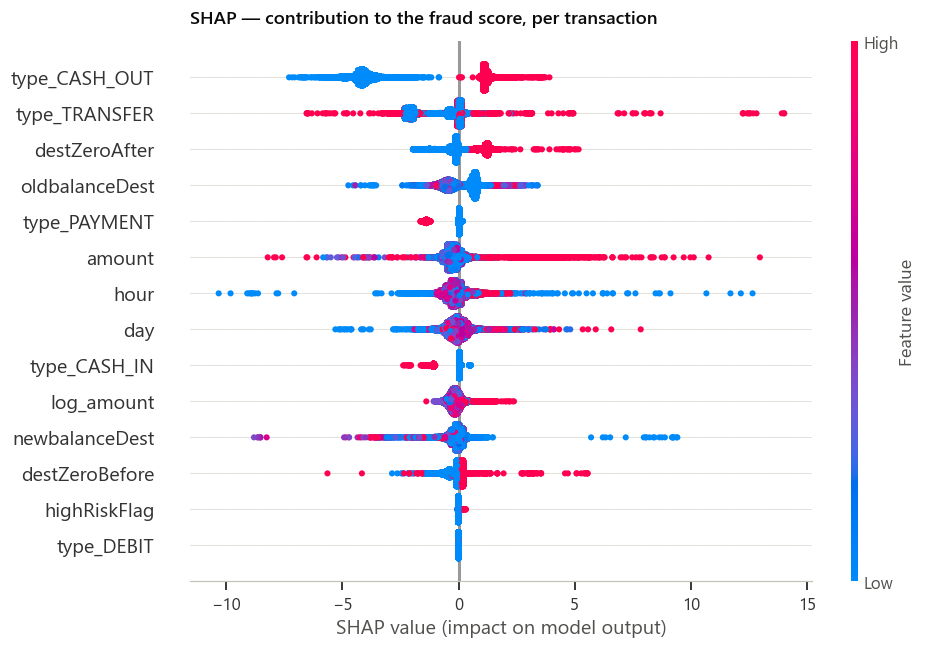

In [7]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_shap, feature_names=cols, show=False,
                  max_display=len(cols), plot_size=None)
plt.title("SHAP  contribution to the fraud score, per transaction",
          loc="left", fontsize=12, fontweight="semibold", pad=12)
plt.tight_layout()
viz.save_figure(plt.gcf(), "07_shap_beeswarm")
plt.show()

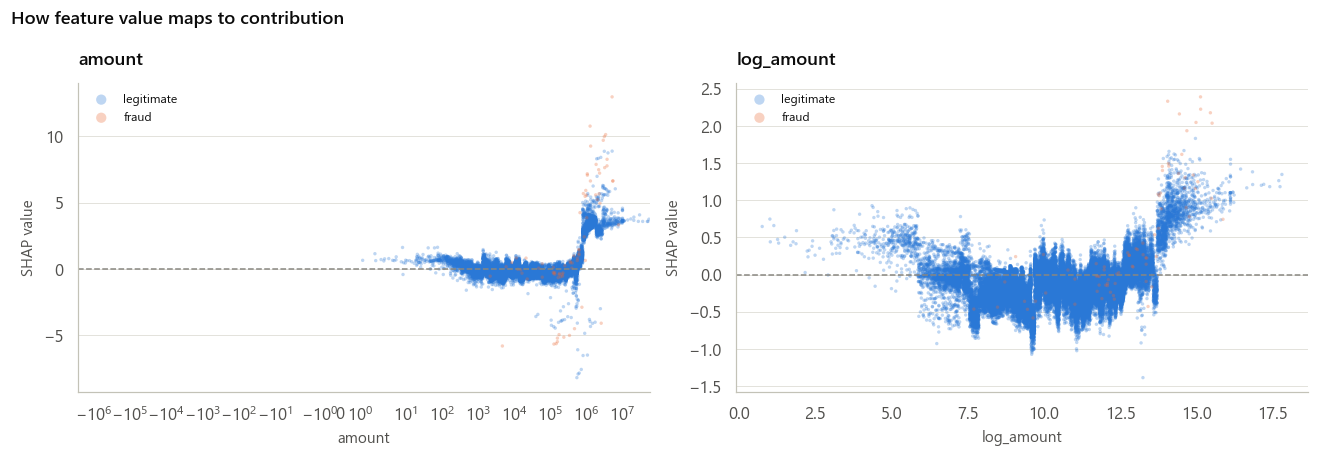

In [8]:
# Dependence for the two features the literature singles out, where present.
focus = [f for f in ("amount", "log_amount", "hour", "newbalanceDest")
         if f in cols][:2]

fig, axes = plt.subplots(1, len(focus), figsize=(6 * len(focus), 4.2))
axes = np.atleast_1d(axes)

for ax, feature in zip(axes, focus):
    j = cols.index(feature)
    values = X_shap[feature].to_numpy()
    is_fraud = y_shap.astype(bool)

    for mask, label, colour in ((~is_fraud, "legitimate", viz.CLASS_COLORS["legitimate"]),
                               (is_fraud, "fraud", viz.CLASS_COLORS["fraud"])):
        ax.scatter(values[mask], shap_values[mask, j], s=5, alpha=0.3,
                   color=colour, label=label, edgecolors="none")

    ax.axhline(0, color=viz.INK["muted"], linewidth=1, linestyle="--")
    if feature in ("amount",):
        ax.set_xscale("symlog")
    ax.set(title=f"{feature}", xlabel=feature, ylabel="SHAP value")
    ax.legend(markerscale=3, fontsize=8)
    viz.despine(ax)

fig.suptitle("How feature value maps to contribution", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "07_shap_dependence")
plt.show()

## Against the published rankings

Lokanan's random-forest importances (his Fig 5) and Thar & Wai's SHAP findings both put **amount** first. Whether that holds once the simulator's origin-balance bookkeeping is removed is the question  if the ranking is stable across the ablation, it is a property of the fraud; if it moves, the published rankings were partly describing the artifact.

In [9]:
# Lokanan (2023) Fig 5, read off the plotted bars  approximate by nature.
LOKANAN_TOP5 = {"amount": 0.29, "type_TRANSFER": 0.23, "newbalanceDest": 0.19,
                "oldbalanceDest": 0.17, "type_CASH_OUT": 0.12}

ours = (mean_abs / mean_abs.sum()).rename("ours")
compare = pd.DataFrame({
    "ours_share": ours.reindex(LOKANAN_TOP5).fillna(0.0),
    "lokanan_share": pd.Series(LOKANAN_TOP5),
})
compare["our_rank"] = [list(ours.index).index(f) + 1 if f in ours.index else None
                       for f in compare.index]
E.save_results(compare.reset_index().rename(columns={"index": "feature"})
               .to_dict("records"), "07_vs_published")
compare.round(4)

,ours_share,lokanan_share,our_rank
amount,0.0507,0.29,6
type_TRANSFER,0.1201,0.23,2
newbalanceDest,0.0291,0.19,11
oldbalanceDest,0.0733,0.17,4
type_CASH_OUT,0.4048,0.12,1


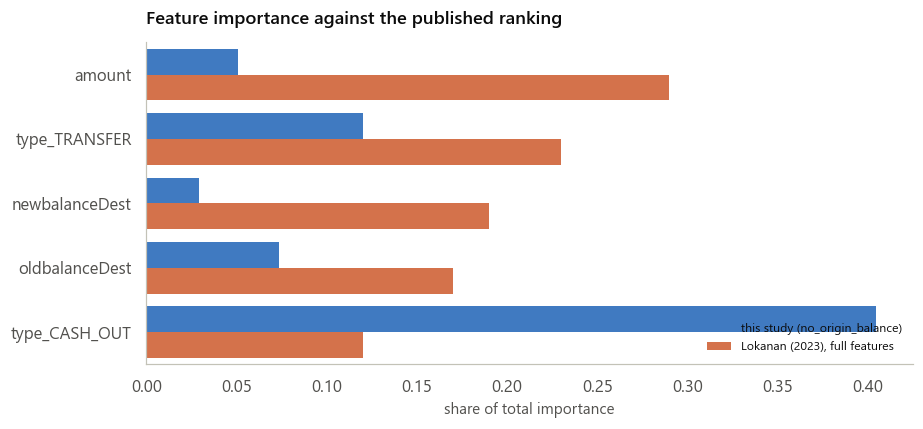

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4))

long = compare.reset_index().melt(id_vars="index",
                                  value_vars=["ours_share", "lokanan_share"],
                                  var_name="source", value_name="share")
long["source"] = long["source"].map({"ours_share": f"this study ({RUNG})",
                                     "lokanan_share": "Lokanan (2023), full features"})

sns.barplot(long, x="share", y="index", hue="source",
            palette=viz.CATEGORICAL[:2], ax=ax)
ax.set(title="Feature importance against the published ranking",
       xlabel="share of total importance", ylabel="")
ax.legend(title="", fontsize=8, loc="lower right")
viz.despine(ax)
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "07_vs_published")
plt.show()

In [11]:
summary = {
    "rung": RUNG,
    "learner": LEARNER,
    "top5_shap": mean_abs.head(5).index.tolist(),
    "top5_permutation": perm_df.head(5)["feature"].tolist(),
    "top5_gain": gain_norm.head(5).index.tolist(),
    "amount_shap_rank": int(list(mean_abs.index).index("amount") + 1)
                        if "amount" in mean_abs.index else None,
}
E.save_json(summary, "07_interpretability_summary")

for key, value in summary.items():
    print(f"  {key:20s} {value}")
print("\nNext: 08_model_export.ipynb  freezing the artifact the prototype loads.")

  rung                 no_origin_balance
  learner              xgboost
  top5_shap            ['type_CASH_OUT', 'type_TRANSFER', 'destZeroAfter', 'oldbalanceDest', 'type_PAYMENT']
  top5_permutation     ['type_TRANSFER', 'newbalanceDest', 'amount', 'destZeroAfter', 'type_CASH_OUT']
  top5_gain            ['destZeroBefore', 'type_TRANSFER', 'destZeroAfter', 'type_CASH_OUT', 'hour']
  amount_shap_rank     6

Next: 08_model_export.ipynb  freezing the artifact the prototype loads.
